In [67]:
from bs4 import BeautifulSoup
import re
import emoji
import string
import contractions
from symspellpy import SymSpell
import pkg_resources
import nltk
    
resources = [
        'punkt',
        'punkt_tab',
        'stopwords',
        'wordnet',
        'omw-1.4',
        'averaged_perceptron_tagger_eng'
    ]
    
for resource in resources:
        nltk.download(resource)
    
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Think\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Think\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Think\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Think\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Think\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Think\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       d

In [38]:
def process_data(text):
       
    text = BeautifulSoup(text, "html.parser").text
          
    text = contractions.fix(text)
     
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    text = re.sub(r'\S+@\S+', '', text)
    
    text = re.sub(r'\+?\d[\d\s-]{8,}\d', '', text)
       
    text = emoji.replace_emoji(text, replace='')
    
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    text = text.lower()
    
    dictionary_path = pkg_resources.resource_filename(
        "symspellpy",
        "frequency_dictionary_en_82_765.txt"
    )
    
    # Create object
    sym_spell = SymSpell(max_dictionary_edit_distance=2)
    
    # Load dictionary
    dictionary_path = pkg_resources.resource_filename(
        "symspellpy",
        "frequency_dictionary_en_82_765.txt"
    )
    
    sym_spell.load_dictionary(
        dictionary_path,
        term_index=0,
        count_index=1
    )
    
    
    suggestions = sym_spell.lookup_compound(
        text,
        max_edit_distance=2
    )
    
    text=suggestions[0].term
    
    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    
    tokens = [word for word in tokens if word not in stop_words]
    
    lemmatizer = WordNetLemmatizer()
    
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    text = " ".join(tokens)
    
    return text

In [39]:
folder_path = r"C:\Users\Think\Desktop\anacondaaa\nlp\plagiarism_corpus_20_docs"

documents = {}

for file in os.listdir(folder_path):
    if file.endswith(".txt"):
        file_path = os.path.join(folder_path, file)

        with open(file_path, "r", encoding="utf-8") as f:
            documents[file] = f.read()

print("Total Documents:", len(documents))

Total Documents: 20


In [40]:
processed_documents = {}
for filename, text in documents.items():
    processed_documents[filename] = process_data(text)

filename = list(documents.keys())[0]

print("Original Document:\n")
print(documents[filename])

print("\n" + "="*60 + "\n")

print("Processed Document:\n")
print(processed_documents[filename])

Original Document:

Artificial Intelligence is transforming modern technology. It helps solve complex problems efficiently. Many industries are adopting Artificial Intelligence to improve productivity and decision making. Researchers continue to improve algorithms and practical applications every year.


Processed Document:

artificial intelligence transforming modern technology help solve complex problem efficiently many industry adopting artificial intelligence improve productivity decision making researcher continue improve algorithm practical application every year


In [45]:
print(len(processed_documents))

20


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [56]:
filenames = list(processed_documents.keys())
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(processed_documents.values())

In [57]:
print(tfidf_matrix.shape)

(20, 90)


In [58]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(tfidf_matrix)
print(similarity_matrix.shape)

(20, 20)


In [65]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=filenames,
    columns=filenames
)

similarity_df = similarity_df.round(4)

similarity_df

,doc_001.txt,doc_002.txt,doc_003.txt,doc_004.txt,doc_005.txt,doc_006.txt,doc_007.txt,doc_008.txt,doc_009.txt,doc_010.txt,doc_011.txt,doc_012.txt,doc_013.txt,doc_014.txt,doc_015.txt,doc_016.txt,doc_017.txt,doc_018.txt,doc_019.txt,doc_020.txt
doc_001.txt,1.0000,0.4915,0.4915,0.4915,0.4915,1.0000,0.4915,0.4915,0.4915,0.4915,0.5359,0.1370,0.1370,0.1370,0.1370,0.0000,0.0000,0.0,0.0453,0.0000
doc_002.txt,0.4915,1.0000,0.4915,0.4915,0.4915,0.4915,1.0000,0.4915,0.4915,0.4915,0.1370,0.5359,0.1370,0.1370,0.1370,0.0000,0.0000,0.0,0.0453,0.0000
doc_003.txt,0.4915,0.4915,1.0000,0.4915,0.4915,0.4915,0.4915,1.0000,0.4915,0.4915,0.1370,0.1370,0.5359,0.1370,0.1370,0.0000,0.0000,0.0,0.0453,0.0000
doc_004.txt,0.4915,0.4915,0.4915,1.0000,0.4915,0.4915,0.4915,0.4915,1.0000,0.4915,0.1370,0.1370,0.1370,0.5359,0.1370,0.0000,0.0000,0.0,0.0453,0.0000
doc_005.txt,0.4915,0.4915,0.4915,0.4915,1.0000,0.4915,0.4915,0.4915,0.4915,1.0000,0.1370,0.1370,0.1370,0.1370,0.5359,0.0000,0.0000,0.0,0.0453,0.0000
doc_006.txt,1.0000,0.4915,0.4915,0.4915,0.4915,1.0000,0.4915,0.4915,0.4915,0.4915,0.5359,0.1370,0.1370,0.1370,0.1370,0.0000,0.0000,0.0,0.0453,0.0000
doc_007.txt,0.4915,1.0000,0.4915,0.4915,0.4915,0.4915,1.0000,0.4915,0.4915,0.4915,0.1370,0.5359,0.1370,0.1370,0.1370,0.0000,0.0000,0.0,0.0453,0.0000
doc_008.txt,0.4915,0.4915,1.0000,0.4915,0.4915,0.4915,0.4915,1.0000,0.4915,0.4915,0.1370,0.1370,0.5359,0.1370,0.1370,0.0000,0.0000,0.0,0.0453,0.0000
doc_009.txt,0.4915,0.4915,0.4915,1.0000,0.4915,0.4915,0.4915,0.4915,1.0000,0.4915,0.1370,0.1370,0.1370,0.5359,0.1370,0.0000,0.0000,0.0,0.0453,0.0000
doc_010.txt,0.4915,0.4915,0.4915,0.4915,1.0000,0.4915,0.4915,0.4915,0.4915,1.0000,0.1370,0.1370,0.1370,0.1370,0.5359,0.0000,0.0000,0.0,0.0453,0.0000


In [62]:
threshold = 0.70

for i in range(len(filenames)):
    for j in range(i + 1, len(filenames)):   # avoids duplicate comparisons
        score = similarity_matrix[i][j]

        if score >= threshold:
            print(f"{filenames[i]}  <-->  {filenames[j]} : {score*100:.2f}%")

doc_001.txt  <-->  doc_006.txt : 100.00%
doc_002.txt  <-->  doc_007.txt : 100.00%
doc_003.txt  <-->  doc_008.txt : 100.00%
doc_004.txt  <-->  doc_009.txt : 100.00%
doc_005.txt  <-->  doc_010.txt : 100.00%


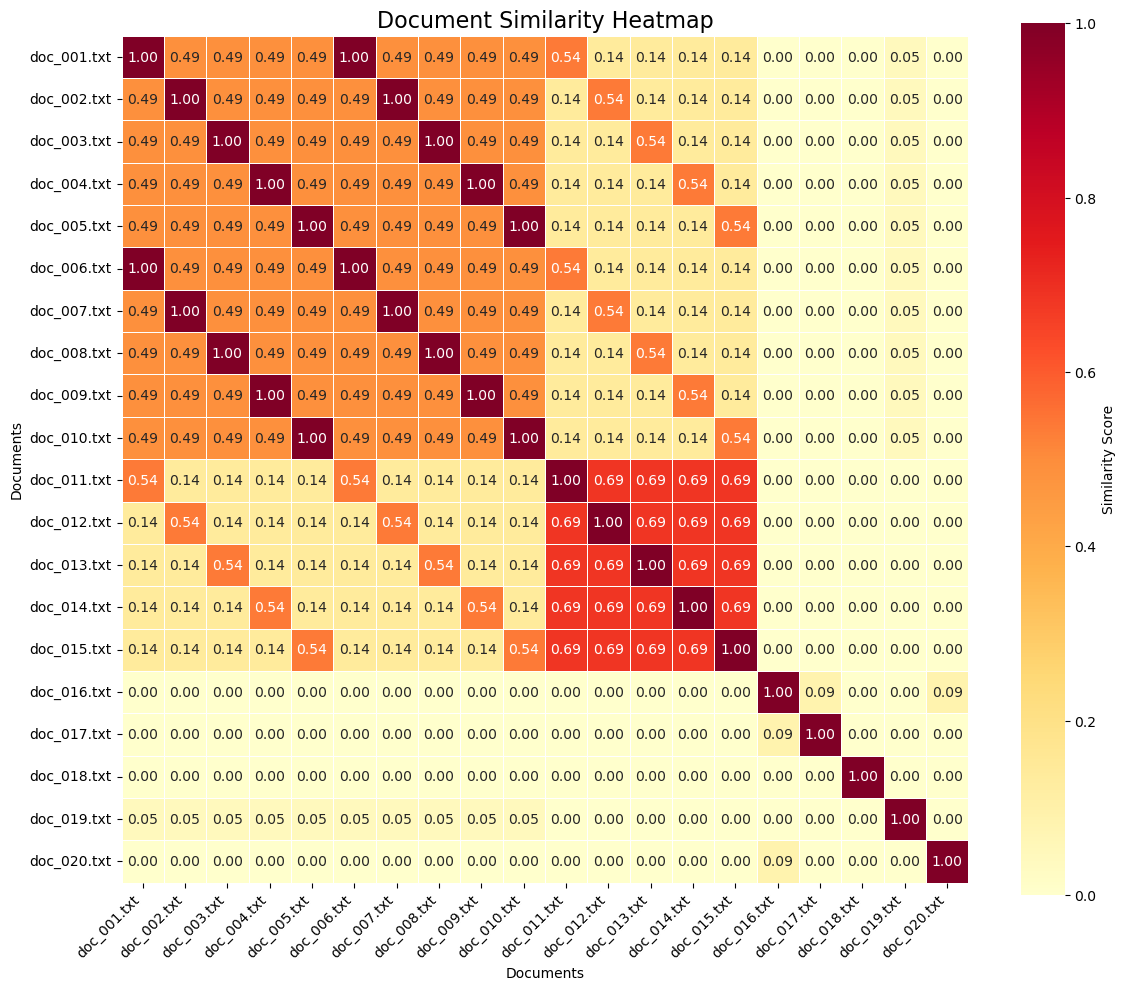

In [68]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    similarity_df,
    annot=True,          # Show similarity values
    fmt=".2f",           # Show 2 decimal places
    cmap="YlOrRd",       # Yellow → Orange → Red
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Similarity Score"}
)

plt.title("Document Similarity Heatmap", fontsize=16)
plt.xlabel("Documents")
plt.ylabel("Documents")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()